In [5]:
import sympy as sp

def compare_gr_and_rg():
    # --- Define Symbols ---
    r, Rs, L = sp.symbols('r Rs L', positive=True, real=True)
    kappa, beta, Q = sp.symbols('kappa beta Q', positive=True, real=True)

    # =====================================================================
    # 1. GENERAL RELATIVITY (GR) DERIVATIONS
    # =====================================================================
    V_eff = (1 - Rs/r) * (1 + L**2/r**2)
    dV_dr = sp.diff(V_eff, r)
    d2V_dr2 = sp.diff(dV_dr, r)

    # Solve for ISCO: V'' = 0 and V' = 0
    L2_isco = sp.solve(d2V_dr2, L**2)[0]
    r_isco_gr = sp.solve(dV_dr.subs(L**2, L2_isco), r)[0]

    # Solve for Photon Sphere: V_phot' = 0
    V_phot = (1 - Rs/r) * (L**2/r**2)
    r_photon_gr = sp.solve(sp.diff(V_phot, r), r)[0]
    r_horizon_gr = Rs

    # =====================================================================
    # 2. WILL RELATIONAL GEOMETRY (RG) DERIVATIONS
    # =====================================================================
    # Q^2 = (3/2)*kappa^2 where kappa^2 = Rs/r
    def get_r(k2): return Rs / k2

    # ISCO: Q^2 = 1/2 => (3/2)*kappa^2 = 1/2
    r_isco_rg = get_r(sp.solve(sp.Eq(sp.Rational(3,2)*kappa**2, sp.Rational(1,2)), kappa**2)[0])

    # Photon Sphere: Q^2 = 1 => (3/2)*kappa^2 = 1
    r_photon_rg = get_r(sp.solve(sp.Eq(sp.Rational(3,2)*kappa**2, 1), kappa**2)[0])
    r_horizon_rg = Rs

    # =====================================================================
    # 3. ANALYSIS AND VERIFICATION
    # =====================================================================
    print("==========================================================")
    print(" COMPLETE PROOF & COMPLEXITY ANALYSIS")
    print("==========================================================\n")

    print(f"GR Results: ISCO={r_isco_gr}, Photon={r_photon_gr}, Horizon={r_horizon_gr}")
    print(f"RG Results: ISCO={r_isco_rg}, Photon={r_photon_rg}, Horizon={r_horizon_rg}")

    print("\n--- MATHEMATICAL IDENTITY PROOF ---")
    print(f"ISCOs are identical:   {r_isco_gr == r_isco_rg}")
    print(f"Photons are identical: {r_photon_gr == r_photon_rg}")
    print(f"Horizons are identical: {r_horizon_gr == r_horizon_rg}")

    print("\n--- COMPLEXITY METRICS (V'' vs Q^2) ---")
    gr_expr = d2V_dr2
    rg_expr = sp.Eq(sp.Rational(3,2)*(Rs/r), sp.Rational(1,2))

    print(f"METRIC                     | GR (Differential) | RG (Algebraic)")
    print(f"---------------------------|-------------------|----------------")
    print(f"Operation Count (raw)      | {sp.count_ops(gr_expr):<17} | {sp.count_ops(rg_expr):<14}")
    print(f"Symbolic Leaf Count        | {len(gr_expr.atoms()):<17} | {len(rg_expr.atoms()):<14}")
    print(f"Expression String Length   | {len(str(gr_expr)):<17} | {len(str(rg_expr)):<14}")

if __name__ == '__main__':
    compare_gr_and_rg()

 COMPLETE PROOF & COMPLEXITY ANALYSIS

GR Results: ISCO=3*Rs, Photon=3*Rs/2, Horizon=Rs
RG Results: ISCO=3*Rs, Photon=3*Rs/2, Horizon=Rs

--- MATHEMATICAL IDENTITY PROOF ---
ISCOs are identical:   True
Photons are identical: True
Horizons are identical: True

--- COMPLEXITY METRICS (V'' vs Q^2) ---
METRIC                     | GR (Differential) | RG (Algebraic)
---------------------------|-------------------|----------------
Operation Count (raw)      | 22                | 5             
Symbolic Leaf Count        | 11                | 5             
Expression String Length   | 69                | 19            


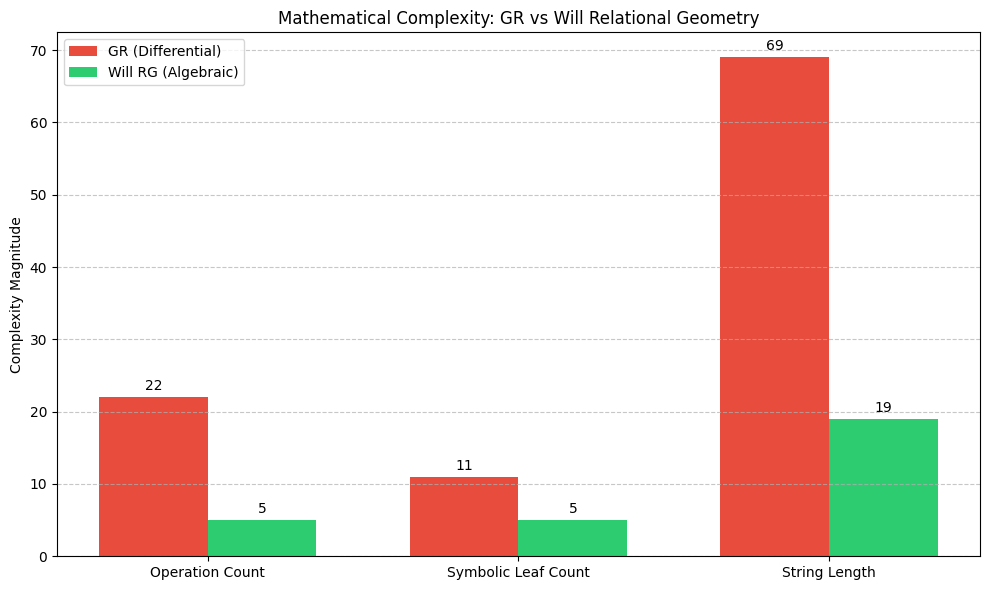

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the symbolic analysis
metrics = ['Operation Count', 'Symbolic Leaf Count', 'String Length']
gr_values = [22, 11, 69]
rg_values = [5, 5, 19]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, gr_values, width, label='GR (Differential)', color='#e74c3c')
rects2 = ax.bar(x + width/2, rg_values, width, label='Will RG (Algebraic)', color='#2ecc71')

# Add labels and styling
ax.set_ylabel('Complexity Magnitude')
ax.set_title('Mathematical Complexity: GR vs Will Relational Geometry')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add value labels on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate('{}'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()